# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




3.0 + 2.0 x + 1.0 x**2
[-1.-1.41421356j -1.+1.41421356j]
[-1.-1.41421356j -1.+1.41421356j]


Pierwiastki W(x) = x^2 + 3x + 2: [-2. -1.]

Pierwiastki obliczone dla oryginalnego wielomianu:
[ 1.          2.          3.          4.00000002  4.99999984  6.00000078
  6.99999766  8.00000426  8.99999644  9.99999742 11.0000111  11.99998569
 13.00000991 13.9999963  15.00000059]


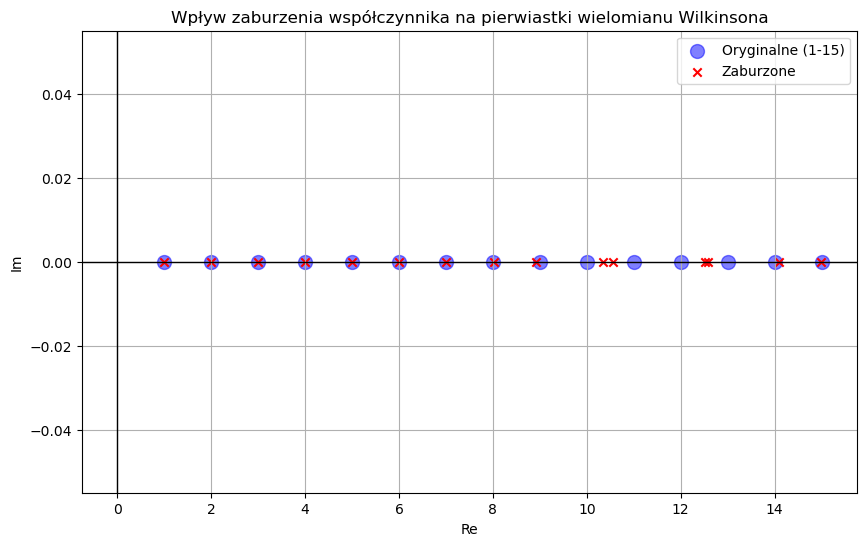

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial


p_quad = Polynomial([2, 3, 1])
print(f"Pierwiastki W(x) = x^2 + 3x + 2: {p_quad.roots()}")


roots_target = np.arange(1, 16)
p_wilk = Polynomial.fromroots(roots_target)


found_roots = p_wilk.roots()
print("\nPierwiastki obliczone dla oryginalnego wielomianu:")
print(np.sort(found_roots))


coeffs_perturbed = p_wilk.coef.copy()
coeffs_perturbed[12] += 1e-5 

p_pert = Polynomial(coeffs_perturbed)
roots_perturbed = p_pert.roots()


plt.figure(figsize=(10, 6))
plt.scatter(roots_target, np.zeros_like(roots_target), color='blue', marker='o', label='Oryginalne (1-15)', s=100, alpha=0.5)
plt.scatter(roots_perturbed.real, roots_perturbed.imag, color='red', marker='x', label='Zaburzone')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Wpływ zaburzenia współczynnika na pierwiastki wielomianu Wilkinsona")
plt.xlabel("Re")
plt.ylabel("Im")
plt.legend()
plt.grid(True)
plt.show()

***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

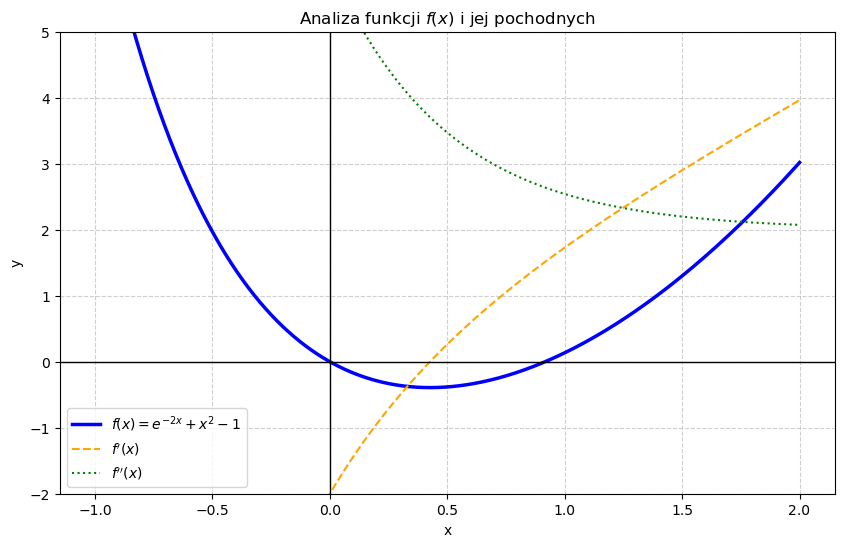

In [10]:
import numpy as np
import matplotlib.pyplot as plt


f = lambda x: np.exp(-2*x) + x**2 - 1
df = lambda x: -2*np.exp(-2*x) + 2*x
ddf = lambda x: 4*np.exp(-2*x) + 2

x = np.linspace(-1, 2, 500)

plt.figure(figsize=(10, 6))
plt.plot(x, f(x), label='$f(x) = e^{-2x} + x^2 - 1$', lw=2.5, color='blue')
plt.plot(x, df(x), label="$f'(x)$", linestyle='--', color='orange')
plt.plot(x, ddf(x), label="$f''(x)$", linestyle=':', color='green')


plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Analiza funkcji $f(x)$ i jej pochodnych")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.ylim(-2, 5)
plt.show()

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

In [12]:
import numpy as np

def bisection(f, a, b, tol, max_iter):
    if f(a) * f(b) >= 0:
        raise ValueError("Funkcja musi mieć różne znaki na końcach przedziału [a, b].")
    
    iters = 0
    while iters < max_iter:
        iters += 1
        c = (a + b) / 2
        
        if abs(b - a) / 2 < tol or f(c) == 0:
            return c, iters
        
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
            
    return (a + b) / 2, iters

def newton_raphson(f, df, x0, tol, max_iter):
    x_curr = x0
    iters = 0
    
    while iters < max_iter:
        iters += 1
        fx = f(x_curr)
        dfx = df(x_curr)
        
        if abs(dfx) < 1e-12:
            raise ZeroDivisionError("Pochodna bliska zeru. Metoda Newtona zawiodła.")
            
        x_next = x_curr - fx / dfx
        
        if abs(x_next - x_curr) < tol:
            return x_next, iters
            
        x_curr = x_next
        
    return x_curr, iters

def secant(f, x0, x1, tol, max_iter):
    iters = 0
    while iters < max_iter:
        iters += 1
        fx0 = f(x0)
        fx1 = f(x1)
        
        if abs(fx1 - fx0) < 1e-12:
            raise ZeroDivisionError("Mianownik bliski zeru w metodzie siecznych.")
            
        x_next = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        
        if abs(x_next - x1) < tol:
            return x_next, iters
            
        x0, x1 = x1, x_next
        
    return x1, iters

***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


In [16]:
import pandas as pd

tol = 1e-6
max_it = 100
results = []

results.append(["Bisekcja", "x1=0", *bisection(f, -0.4, 0.6, tol, max_it)])
results.append(["Newton", "x1=0", *newton_raphson(f, df, 0.4, tol, max_it)])
results.append(["Sieczne", "x1=0", *secant(f, -0.2, 0.2, tol, max_it)])

results.append(["Bisekcja", "x2~0.91", *bisection(f, 0.5, 1.5, tol, max_it)])
results.append(["Newton", "x2~0.91", *newton_raphson(f, df, 1.5, tol, max_it)])
results.append(["Sieczne", "x2~0.91", *secant(f, 0.7, 1.2, tol, max_it)])

df_results = pd.DataFrame(results, columns=["Metoda", "Cel", "Znaleziony x", "Iteracje"])
print("PORÓWNANIE METOD NUMERYCZNYCH")
print("-" * 50)
print(df_results.to_string(index=False))

tol = 1e-12
max_it = 100
results = []

results.append(["Bisekcja", "x1=0", *bisection(f, -0.4, 0.6, tol, max_it)])
results.append(["Newton", "x1=0", *newton_raphson(f, df, 0.4, tol, max_it)])
results.append(["Sieczne", "x1=0", *secant(f, -0.2, 0.2, tol, max_it)])

results.append(["Bisekcja", "x2~0.91", *bisection(f, 0.5, 1.5, tol, max_it)])
results.append(["Newton", "x2~0.91", *newton_raphson(f, df, 1.5, tol, max_it)])
results.append(["Sieczne", "x2~0.91", *secant(f, 0.7, 1.2, tol, max_it)])

df_results = pd.DataFrame(results, columns=["Metoda", "Cel", "Znaleziony x", "Iteracje"])
print("PORÓWNANIE METOD NUMERYCZNYCH")
print("-" * 50)
print(df_results.to_string(index=False))

PORÓWNANIE METOD NUMERYCZNYCH
--------------------------------------------------
  Metoda     Cel  Znaleziony x  Iteracje
Bisekcja    x1=0  5.722046e-07        20
  Newton    x1=0 -7.876900e-18        13
 Sieczne    x1=0  3.349187e-11         6
Bisekcja x2~0.91  9.165621e-01        20
  Newton x2~0.91  9.165626e-01         5
 Sieczne x2~0.91  9.165626e-01         6
PORÓWNANIE METOD NUMERYCZNYCH
--------------------------------------------------
  Metoda     Cel  Znaleziony x  Iteracje
Bisekcja    x1=0  5.456746e-13        40
  Newton    x1=0 -7.876900e-18        14
 Sieczne    x1=0  6.025230e-18         8
Bisekcja x2~0.91  9.165626e-01        40
  Newton x2~0.91  9.165626e-01         6
 Sieczne x2~0.91  9.165626e-01         7


***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

C:\Users\adams\AppData\Local\Temp\ipykernel_12876\366099854.py:30: RuntimeWarning: invalid value encountered in scalar divide
  x_next = x1 - fx1 * (x1 - x0) / (fx1 - fx0)


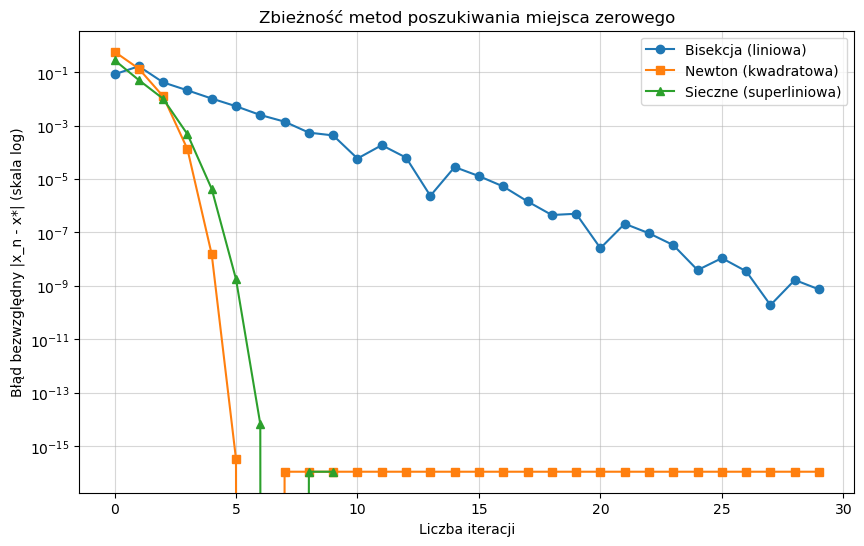

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Definicja funkcji
f = lambda x: np.exp(-2*x) + x**2 - 1
df = lambda x: -2*np.exp(-2*x) + 2*x

def bisection_history(f, a, b, max_iter):
    history = []
    for _ in range(max_iter):
        c = (a + b) / 2
        history.append(c)
        if f(a) * f(c) < 0: b = c
        else: a = c
    return np.array(history)

def newton_history(f, df, x0, max_iter):
    history = []
    x_curr = x0
    for _ in range(max_iter):
        history.append(x_curr)
        x_curr = x_curr - f(x_curr) / df(x_curr)
    return np.array(history)

def secant_history(f, x0, x1, max_iter):
    history = []
    for _ in range(max_iter):
        history.append(x1)
        fx0, fx1 = f(x0), f(x1)
        x_next = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        x0, x1 = x1, x_next
    return np.array(history)

# Parametry testu dla pierwiastka x2 ≈ 0.91656
max_it = 30
root_true = 0.916562583105698 # wartość referencyjna

hist_bis = bisection_history(f, 0.5, 1.5, max_it)
hist_new = newton_history(f, df, 1.5, max_it)
hist_sec = secant_history(f, 0.7, 1.2, max_it)

# Obliczanie błędu w każdym kroku
err_bis = np.abs(hist_bis - root_true)
err_new = np.abs(hist_new - root_true)
err_sec = np.abs(hist_sec - root_true)

# Wykres
plt.figure(figsize=(10, 6))
plt.semilogy(range(max_it), err_bis, 'o-', label='Bisekcja (liniowa)')
plt.semilogy(range(max_it), err_new, 's-', label='Newton (kwadratowa)')
plt.semilogy(range(max_it), err_sec, '^-', label='Sieczne (superliniowa)')

plt.title("Zbieżność metod poszukiwania miejsca zerowego")
plt.xlabel("Liczba iteracji")
plt.ylabel("Błąd bezwzględny |x_n - x*| (skala log)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()